Question 1

Download a daily temperature dataset for an Indian city and plot the raw temperature data to identify trend and seasonality patterns.

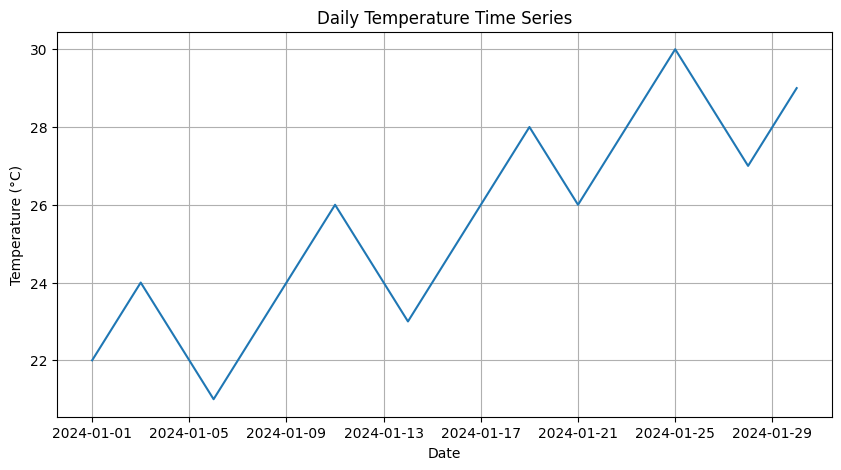

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Aaryan\data science\machine learning\temperatures.csv")

df["Date"] = pd.to_datetime(df["Date"])

plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Temperature"])

plt.title("Daily Temperature Time Series")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

Question 2

Decompose the temperature time series into trend, seasonal, and residual components using seasonal_decompose().

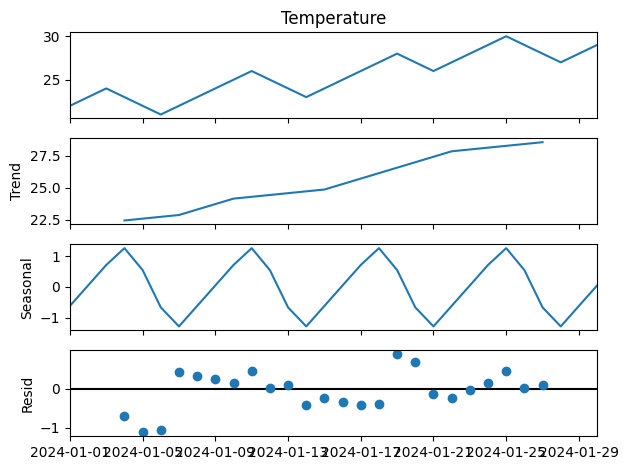

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv(r"C:\Users\Aaryan\data science\machine learning\temperatures.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

result = seasonal_decompose(
    df["Temperature"],
    model="additive",
    period=7
)

result.plot()

plt.show()

Question 3

Check whether the temperature series is stationary using the Augmented Dickey-Fuller (ADF) Test.

In [21]:
import pandas as pd

from statsmodels.tsa.stattools import adfuller

df = pd.read_csv(r"C:\Users\Aaryan\data science\machine learning\temperatures.csv")

result = adfuller(df["Temperature"])

print("ADF Statistic:", result[0])

print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -0.49093072810403143
p-value: 0.8937741862268223
Series is Non-Stationary


Question 4

Apply a moving average smoothing technique (window size 7) to your time series and plot both the original and smoothed series on the same graph to compare.

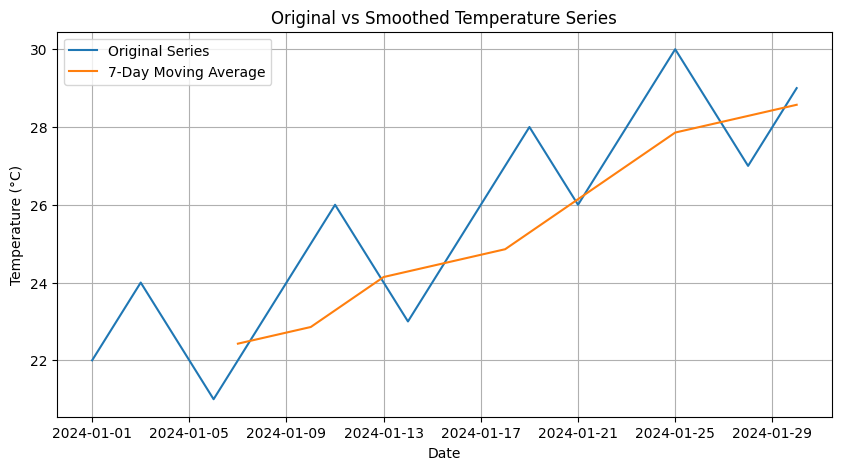

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Aaryan\data science\machine learning\temperatures.csv")

df["Date"] = pd.to_datetime(df["Date"])

df["Moving_Average"] = (
    df["Temperature"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    df["Date"],
    df["Temperature"],
    label="Original Series"
)

plt.plot(
    df["Date"],
    df["Moving_Average"],
    label="7-Day Moving Average"
)

plt.title("Original vs Smoothed Temperature Series")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(True)

plt.show()

Question 5

Fit an ARIMA model to your temperature data and forecast the next 7 days. Display the predicted values and plot them along with the original series.

c:\Users\Aaryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Aaryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Aaryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Forecasted Temperatures
2024-01-31    29.306134
2024-02-01    29.366886
2024-02-02    29.378942
2024-02-03    29.381335
2024-02-04    29.381810
2024-02-05    29.381904
2024-02-06    29.381923
Freq: D, Name: predicted_mean, dtype: float64


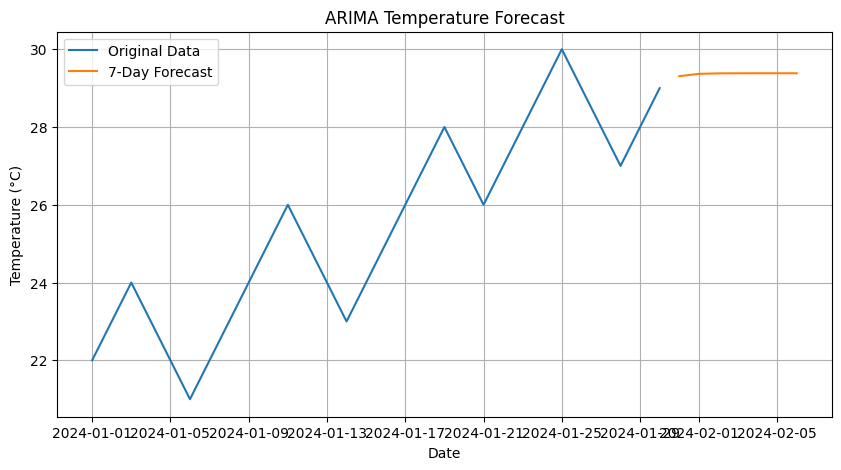

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv(r"C:\Users\Aaryan\data science\machine learning\temperatures.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

model = ARIMA(
    df["Temperature"],
    order=(1,1,1)
)

model_fit = model.fit()

forecast = model_fit.forecast(steps=7)

print("Forecasted Temperatures")

print(forecast)

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=7
)

plt.figure(figsize=(10,5))

plt.plot(
    df.index,
    df["Temperature"],
    label="Original Data"
)

plt.plot(
    future_dates,
    forecast,
    label="7-Day Forecast"
)

plt.title("ARIMA Temperature Forecast")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(True)

plt.show()